# Tratamento de Dados — Computer Prices

Notebook responsável por preparar o dataset bruto `computer_prices_train_80.csv` para a etapa de modelagem. O pipeline executa as seguintes etapas, nesta ordem:

| Etapa | Descrição |
|-------|-----------|
| (1.0) | Importação de bibliotecas e carregamento dos dados |
| (2.0) | Tratamento das variáveis categóricas (encoding + one-hot) |
| (3.0) | Remoção de colunas colineares (definição) |
| (4.0) | Engenharia de features — correção de viés (definição) |
| (5.0) | Engenharia de features — sinergia e mobilidade (definição) |
| (6.0) | Aplicação do pipeline de tratamento |
| (7.0) | Análise de correlação com o alvo |
| (8.0) | Detecção de multicolinearidade entre features |
| (9.0) | Seleção de features (Linear vs. Tree) |
| (10.0) | Higienização via CatBoost (remoção de outliers) |
| (11.0) | Exportação dos datasets limpos |
| (12.0) | Abordagem alternativa — remoção por percentil |

**Saída esperada:** três CSVs em `csv_gerados/` — `linear.csv`, `tree.csv` e `tree_alternativo.csv` (além das versões `_exemplo` com 20 linhas).

In [1]:
# Importando bibliotecas dessa análise
import os
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from catboost import CatBoostRegressor

from utils import (
    plot_correlacao_alvo,
    analisar_multicolinearidade_pares,
    normalizar_variaveis_numericas
)

%load_ext autoreload
%autoreload 2

# Configuração de estilo para os gráficos 
sns.set_theme(style="whitegrid")

# Ignorar avisos 
import warnings
warnings.filterwarnings('ignore')

caminho = os.path.join(os.getcwd(), 'Arquivos', 'computer_prices_train_80.csv')

df = pd.read_csv(caminho)
df['price_log'] = np.log1p(df['price'])


df_tratado = df.copy()

# (2.0) Tratamento das Variáveis Categóricas

Função `tratar_variaveis_categoricas`: converte todas as variáveis categóricas em representações numéricas compatíveis com os modelos de machine learning.

**Etapas internas:**

1. **Label Encoding (variáveis ordinais)** — aplica um mapeamento manual que preserva a ordem natural das categorias:
   - `wifi`: Wi-Fi 5 (1) → Wi-Fi 7 (4)
   - `storage_type`: HDD (1) → NVMe (4)
   - `display_type`: LED (1) → OLED (6)

2. **Transformação de `resolution`** — separa largura e altura, calcula o total de pixels (`total_pixels`) e normaliza com `MinMaxScaler`, gerando a coluna `resolution_norm` no intervalo `[0, 1]`. As colunas auxiliares `resolution` e `total_pixels` são removidas.

3. **Remoção de colunas de alta cardinalidade** — `model`, `cpu_model`, `gpu_model` e `ID` são descartadas porque têm muitas categorias distintas e não agregam valor preditivo generalizável.

4. **One-Hot Encoding** — aplicado nas variáveis nominais restantes (`brand`, `os`, `device_type`, `form_factor` etc.), gerando colunas binárias.

5. **Conversão de booleanos para `int`** — garante que as colunas resultantes do One-Hot sejam `0/1` em vez de `True/False`, evitando problemas em bibliotecas que não aceitam `bool`.

**Dependências criadas:** a coluna `resolution_norm` é usada posteriormente por `correcao_feature` e incluída no dataset `df_linear`.

In [2]:
def tratar_variaveis_categoricas(df_original):
    df_original = df_original.copy()

    ##########################################

    # Tratando variáveis categóricas:

    ###########################################


    # (1) Label Encoding (Variáveis categóricas ordinais)
    mapa_wifi = {'Wi-Fi 5': 1, 'Wi-Fi 6': 2, 'Wi-Fi 6E': 3, 'Wi-Fi 7': 4}
    mapa_storage = {'HDD': 1, 'Hybrid': 2, 'SSD': 3, 'NVMe': 4}
    mapa_display = {'LED': 1, 'VA': 2, 'IPS': 3, 'QLED': 4, 'Mini-LED': 5, 'OLED': 6}

    df_original['wifi'] = df_original['wifi'].map(mapa_wifi)
    df_original['storage_type'] = df_original['storage_type'].map(mapa_storage)
    df_original['display_type'] = df_original['display_type'].map(mapa_display)

    # (2) Transformar e Normalizar Resolution:

    dimensoes = df_original['resolution'].str.split('x', expand=True).astype(float)

    df_original['total_pixels'] = dimensoes[0] * dimensoes[1]

    scaler = MinMaxScaler() #normalizacao
    df_original['resolution_norm'] = scaler.fit_transform(df_original[['total_pixels']])

    df_original = df_original.drop(columns=['resolution', 'total_pixels']) #removendo colunas extras

    #####################################################################################


    # (3) Removendo colunas com alta cardinalidade e ruins para treinar o modelo final:

    colunas_remover = ['model', 'cpu_model', 'gpu_model', 'ID']
    df_original = df_original.drop(columns=[c for c in colunas_remover if c in df_original.columns], errors='ignore')

    # (4) One Hot Enconding para as variáveis categóricas nominais restantes (brand, os, device_type, etc.):

    cols_categoricas_restantes = df_original.select_dtypes(include=['object', 'category']).columns # resto das colunas

    df_original = pd.get_dummies(df_original, columns=cols_categoricas_restantes, drop_first=True)

    # (5) Garante que os booleanos do One-Hot virem inteiros (0 e 1) em vez de True/False
    cols_booleanas = df_original.select_dtypes(include=['bool']).columns
    df_original[cols_booleanas] = df_original[cols_booleanas].astype(int)

    return df_original

# (3.0) Remoção de Colunas Colineares

Função `remover_colunas_colinares`: elimina variáveis redundantes que prejudicam a estabilidade de modelos lineares (Ridge, Lasso) e inflacionam a importância relativa em modelos baseados em árvore.

**Colunas removidas e justificativa:**

| Coluna | Motivo |
|--------|--------|
| `price` | Target original — o modelo usa `price_log` |
| `cpu_boost_ghz` | Redundante com `cpu_base_ghz` |
| `cpu_threads` | Redundante com `cpu_cores` |
| `cpu_tier` | Variável sintética que inflaciona correlações |
| `battery_wh` | Redundante com `device_type` |
| `psu_watts` | Redundante com `device_type` |
| `weight_kg` | Redundante com tamanho e `device_type` |

**Observação:** essa função é aplicada **por último** no pipeline (etapa 6.0), preservando as features sintéticas criadas por `aplicar_feature_engineering` (que dependem de `cpu_tier`, `battery_wh`, `weight_kg`, `cpu_boost_ghz` em seus cálculos).

In [3]:
def remover_colunas_colinares(df_original):
    colunas_colineares = [
        'price',          # Target original (usaremos price_log)
        'cpu_boost_ghz',  # Redundante com base_ghz
        'cpu_threads',    # Redundante com cpu_cores
        'cpu_tier',       # Variável sintética que inflaciona tudo
        'battery_wh',     # Redundante com device_type
        'psu_watts',      # Redundante com device_type
        'weight_kg'       # Redundante com tamanho e device_type
]
    

    # Drop final no dataset já transformado
    return df_original.drop(columns=colunas_colineares, errors='ignore')


# (4.0) Engenharia de Features — Correção de Viés

Função `correcao_feature`: cria features de interação que corrigem vieses sistemáticos que o modelo teria com certas categorias de hardware.

**Features da cauda direita (efeito "Apple Tax"):**

| Feature | Interação | O que captura |
|---------|-----------|---------------|
| `apple_ram_gb` | `brand_Apple * ram_gb` | Prêmio de preço por RAM em produtos Apple |
| `apple_cpu_cores` | `brand_Apple * cpu_cores` | Prêmio por núcleos Apple |
| `apple_gpu_premium` | `brand_Apple * gpu_tier` | Prêmio de GPU Apple |
| `apple_resolution` | `brand_Apple * resolution_norm` | Prêmio por telas de alta resolução Apple |

Sem essas interações, o modelo tenderia a subestimar máquinas Apple (pagando menos do que valem) e superestimar PCs com hardware equivalente.

**Features da cauda esquerda (depreciação temporal):**

| Feature | Interação | O que captura |
|---------|-----------|---------------|
| `gpu_power_by_year` | `gpu_tier * release_year` | Evita que GPU antigo tenha preço de GPU atual |
| `cpu_power_by_year` | `cpu_cores * release_year` | Evita que CPU antigo tenha preço de CPU atual |
| `is_compact_desktop` | `form_factor_SFF * (1 - device_type_Laptop)` | Flag para desktops SFF (não-laptops compactos) |

**Dependências:** usa `resolution_norm`, `form_factor_SFF`, `brand_Apple` e `device_type_Laptop`, portanto precisa rodar depois de `tratar_variaveis_categoricas`.

In [4]:
def correcao_feature(df_original):
    # Cria uma cópia para não alterar o dataset original acidentalmente
    df_copia = df_original.copy()
    
    # ==========================================
    # FEATURES DA CAUDA DIREITA (O "Apple Tax")
    # ==========================================
    # Interações com RAM e Processamento
    df_copia['apple_ram_gb'] = df_copia['brand_Apple'] * df_copia['ram_gb']
    df_copia['apple_cpu_cores'] = df_copia['brand_Apple'] * df_copia['cpu_cores']
    
    # Interação com GPU e Tela
    df_copia['apple_gpu_premium'] = df_copia['brand_Apple'] * df_copia['gpu_tier'] 
    df_copia['apple_resolution'] = df_copia['brand_Apple'] * df_copia['resolution_norm']
    
    # ==========================================
    # FEATURES DA CAUDA ESQUERDA (Superestimações)
    # ==========================================
    # Interação de Depreciação Temporal 
    # Força a árvore a cruzar a potência bruta com o ano de lançamento,
    # impedindo que o modelo cobre preço de hardware atual em peças antigas.
    df_copia['gpu_power_by_year'] = df_copia['gpu_tier'] * df_copia['release_year']
    df_copia['cpu_power_by_year'] = df_copia['cpu_cores'] * df_copia['release_year']
    
    # Fator Desktop/Mini-PC vs Laptop
    # Cria uma flag clara para dispositivos que NÃO são laptops, mas têm formato pequeno (SFF)
    df_copia['is_compact_desktop'] = df_copia['form_factor_SFF'] * (1 - df_copia['device_type_Laptop'])
    
    return df_copia

In [5]:
def aplicar_feature_engineering(df):
    df_copia = df.copy()
    
    # Prevenção de divisão por zero (adicionando um epsilon mínimo onde necessário)
    epsilon = 1e-5
    
    # 1. Sinergia de Hardware

    #Power Index --> avalia a "potência do computador baseado nos principais indices"
    df_copia['power_index'] = df_copia['cpu_tier'] * df_copia['gpu_tier'] * df_copia['ram_gb'] 

    #Ram pelo core --> importante para futuras análises dos modelos de árvore
    df_copia['ram_per_core'] = df_copia['ram_gb'] / (df_copia['cpu_cores'] + epsilon)
    
    # 2. Design e Mobilidade Premium

    #avalia bateria / peso
    df_copia['battery_density'] = df_copia['battery_wh'] / (df_copia['weight_kg'] + epsilon)

    #Peso/tamanho --> computadores mais caros tendem a ser mais compactos
    df_copia['weight_per_inch'] = df_copia['weight_kg'] / (df_copia['display_size_in'] + epsilon)
    
    # Avalia o processador ( muito importante)
    df_copia['cpu_turbo_range'] = df_copia['cpu_boost_ghz'] - df_copia['cpu_base_ghz']
    
    return df_copia

# Aplique tanto no X_tree_limpo quanto na base de validação/teste secreta


# (5.0) Engenharia de Features — Sinergia e Mobilidade

Função `aplicar_feature_engineering`: cria features derivadas que capturam sinergia entre componentes de hardware e características físicas de mobilidade.

**Features geradas:**

| Feature | Fórmula | Interpretação |
|---------|---------|---------------|
| `power_index` | `cpu_tier * gpu_tier * ram_gb` | Potência bruta combinada do sistema |
| `ram_per_core` | `ram_gb / cpu_cores` | Proporção de memória por núcleo |
| `battery_density` | `battery_wh / weight_kg` | Eficiência energética por kg |
| `weight_per_inch` | `weight_kg / display_size_in` | Compacidade do dispositivo |
| `cpu_turbo_range` | `cpu_boost_ghz - cpu_base_ghz` | Faixa de turbo do processador |

**Restrição de ordem:** usa colunas que serão removidas em (6.0) por `remover_colunas_colinares` (`cpu_tier`, `battery_wh`, `weight_kg`, `cpu_boost_ghz`). Por isso, **precisa rodar antes da remoção**.

**Aplicação:** deve ser aplicada também em qualquer base de validação/teste futura para manter consistência de features.

# (6.0) Aplicação do Pipeline de Tratamento

Aplicação sequencial de todas as funções de tratamento sobre o dataset, produzindo o DataFrame final `df_tratado`.

**Ordem de execução (com dependências):**

| # | Função | Entrada | Saída |
|---|--------|---------|-------|
| 1 | `tratar_variaveis_categoricas` | df bruto | encodings + `resolution_norm` |
| 2 | `aplicar_feature_engineering` | usa colunas **brutas** (`cpu_tier`, `battery_wh`, `weight_kg`, `cpu_boost_ghz`) | +5 features sintéticas |
| 3 | `correcao_feature` | precisa de `resolution_norm` e `form_factor_SFF` | +7 features de interação |
| 4 | `normalizar_variaveis_numericas` | todas numéricas | variáveis escalonadas |
| 5 | `remover_colunas_colinares` | por último | remove redundâncias preservando as features recém-criadas |

**Por que essa ordem?** `aplicar_feature_engineering` (2) depende de colunas que `remover_colunas_colinares` (5) descartaria, então ela precisa rodar antes. `correcao_feature` (3) depende de `resolution_norm`, criada em (1). A normalização (4) é feita antes da remoção final (5) para que as features sintéticas também sejam escalonadas.

In [6]:
df_tratado = tratar_variaveis_categoricas(df_tratado)
df_tratado = aplicar_feature_engineering(df_tratado)
df_tratado = correcao_feature(df_tratado)
df_tratado = normalizar_variaveis_numericas(df_tratado)
df_tratado = remover_colunas_colinares(df_tratado)

# (7.0) Análise de Correlação com o Alvo

Cálculo da **correlação de Pearson** entre todas as features e o target `price_log`, exibindo as 20 mais relevantes.

**Objetivo:** identificar quais variáveis têm maior poder preditivo sobre o preço dos computadores e validar a utilidade das features de interação criadas.

**Observação:** a correlação de Pearson mede apenas relações lineares — features com baixa correlação aqui ainda podem ser úteis para modelos baseados em árvore, que capturam relações não-lineares e interações.

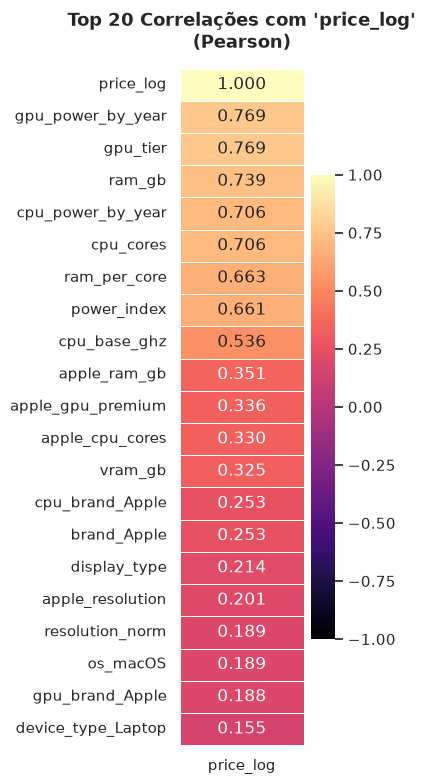

,price_log
price_log,1.000000
gpu_power_by_year,0.768793
gpu_tier,0.768610
ram_gb,0.739125
cpu_power_by_year,0.705971
cpu_cores,0.705787
ram_per_core,0.663385
power_index,0.660701
cpu_base_ghz,0.536237
apple_ram_gb,0.350774


In [7]:
from utils import plot_correlacao_alvo, analisar_multicolinearidade_pares

df_todas_correlacoes = plot_correlacao_alvo(
    df=df_tratado, 
    alvo='price_log', 
    top_n=20, 
    metodo='pearson', 
    cor='magma',
)


display(df_todas_correlacoes)

# (8.0) Detecção de Multicolinearidade entre Features

Identificação de **pares de features com correlação acima de 0,80**, indicando redundância entre preditores.

**Por que importa:** features altamente correlacionadas entre si podem:
- **Desestabilizar modelos lineares** (Ridge, Lasso), tornando os coeficientes sensíveis a pequenas variações nos dados
- **Inflacionar a importância relativa** em modelos baseados em árvore, que dividem o "ganho" entre features redundantes

**Ação tomada:** a partir desses pares, selecionamos representantes isolados para compor o `df_linear` (etapa 9.0). Para modelos baseados em árvore (`df_tree`), mantemos todas as features — a redundância é menos crítica nesses modelos.

In [8]:
analisar_multicolinearidade_pares(df_tratado, limite=0.80)

--- Pares com Correlação > 0.8 ---
brand_Apple & cpu_brand_Apple: 1.000
form_factor_SFF & is_compact_desktop: 1.000
gpu_tier & gpu_power_by_year: 1.000
cpu_cores & cpu_power_by_year: 1.000
apple_cpu_cores & apple_gpu_premium: 0.965
apple_ram_gb & apple_cpu_cores: 0.960
apple_ram_gb & apple_gpu_premium: 0.958
ram_gb & power_index: 0.954
display_size_in & device_type_Laptop: 0.940
gpu_tier & ram_gb: 0.913
ram_gb & gpu_power_by_year: 0.913
brand_Apple & apple_gpu_premium: 0.908
cpu_brand_Apple & apple_gpu_premium: 0.908
cpu_cores & ram_gb: 0.907
ram_gb & cpu_power_by_year: 0.907
device_type_Laptop & battery_density: 0.898
brand_Apple & apple_cpu_cores: 0.895
cpu_brand_Apple & apple_cpu_cores: 0.895
power_index & cpu_power_by_year: 0.887
cpu_cores & power_index: 0.887
gpu_tier & ram_per_core: 0.858
ram_per_core & gpu_power_by_year: 0.858
display_size_in & battery_density: 0.855
ram_gb & ram_per_core: 0.849
power_index & gpu_power_by_year: 0.835
gpu_tier & power_index: 0.835
cpu_cores & gpu

# (9.0) Seleção de Features para Modelos Lineares

Criação de dois datasets distintos, cada um otimizado para uma família de modelos:

| Dataset | Uso | Composição |
|---------|-----|------------|
| `df_linear` | Ridge, Lasso, ElasticNet | Subconjunto enxuto com baixa multicolinearidade |
| `df_tree` | CatBoost, XGBoost, Random Forest | Dataset completo com todas as features |

**Critérios de seleção para `df_linear`:**

1. **Representantes isolados de hardware** — `gpu_tier`, `ram_gb`, `storage_gb`, `cpu_base_ghz` (evita pares colineares como `cpu_cores`/`gpu_tier`)
2. **Representante único do ecossistema Apple** — `brand_Apple` (substitui sozinho `os_macOS` e `gpu_brand_Apple`)
3. **Características físicas e de tela** — `resolution_norm`, `device_type_Laptop`, `form_factor_Gaming`
4. **Idade do hardware** — `release_year` (fator de depreciação temporal)

**Alvo:** ambos os datasets mantêm `price_log` como variável resposta.

In [9]:
colunas_linear= [
    'price_log',           # Alvo
    
    # 1. Representantes Isolados de Hardware
    'gpu_tier',            # Representante principal de força (absorve o peso dos núcleos)
    'ram_gb',              # Essencial (embora correlacionado com GPU, é obrigatório para Lasso/Ridge)
    'storage_gb',          # Omitido antes, mas vital para precificação real
    'cpu_base_ghz',        # Frequência base (menos correlacionada com a RAM que os núcleos)
    
    # 2. Representante Único do Ecossistema Apple
    'brand_Apple',         # Substitui sozinho os_macOS e gpu_brand_Apple
    
    # 3. Características Físicas e Tela
    'resolution_norm',     # Qualidade da tela
    'device_type_Laptop',  # Formato portátil
    'form_factor_Gaming',  # Nicho encarecedor
    
    # 4. Idade do Hardware
    'release_year'         # Fator de depreciação temporal
]

df_linear = df_tratado[colunas_linear]

df_tree = df_tratado.copy()

# (10.0) Higienização: Remoção de Outliers via CatBoost

Treinamento de um **CatBoost provisório** para identificar anomalias no dataset. Linhas com resíduos (erro de previsão) maiores que **±$1000** são consideradas outliers e removidas.

**Fluxo:**

1. Treina um `CatBoostRegressor` com 500 iterações e profundidade 6 no dataset completo
2. Calcula previsões e converte os valores de volta para dólares reais (`expm1` do log)
3. Calcula resíduos: `residuo = preço_real - preço_previsto`
4. Cria máscara que mantém apenas linhas com `-1000 ≤ residuo ≤ 1000`
5. Aplica a máscara simultaneamente em `df_tree` e `df_linear` (garantindo alinhamento das linhas)
6. Gera relatório com quantidade de anomalias removidas


In [10]:
X_tree = df_tree.drop(columns=['price_log'])
y_tree = df_tree['price_log']

X_lin = df_linear.drop(columns=['price_log'])
y_lin = df_linear['price_log']

# 1. Treina um CatBoost provisório só para mapear a sujeira
modelo_filtro = CatBoostRegressor(iterations=500, depth=6, random_seed=42, verbose=False)
modelo_filtro.fit(X_tree, y_tree)

# 2. Gera as previsões e calcula o erro em Dólares
predicoes = np.expm1(modelo_filtro.predict(X_tree))
precos_reais = np.expm1(y_tree)
residuos = precos_reais - predicoes

# 3. Cria a máscara para remover erros absurdos (resíduos > +$1000 ou < -$1000)
mascara_limpa = (residuos >= -1000) & (residuos <= 1000)

# 4. Aplica a higienização simultânea nas bases Tree e Linear
# Dataset Tree
df_tree_limpo = df_tree[mascara_limpa].copy()
X_tree_limpo = df_tree_limpo.drop(columns=['price_log'])
y_tree_limpo = df_tree_limpo['price_log']

# Dataset Linear
df_lin_limpo = df_linear[mascara_limpa].copy()
X_lin_limpo = df_lin_limpo.drop(columns=['price_log'])
y_lin_limpo = df_lin_limpo['price_log']

# 5. Relatório de Limpeza
anomalias_removidas = len(df_tree) - len(df_tree_limpo)
print(f"=== HIGIENIZAÇÃO CONCLUÍDA ===")
print(f"Anomalias removidas: {anomalias_removidas} linhas ({(anomalias_removidas)/len(df_tree)*100:.2f}%)")
print(f"Base Tree Limpa    : {len(X_tree_limpo)} linhas prontas para otimização.")
print(f"Base Linear Limpa  : {len(X_lin_limpo)} linhas preparadas.")

=== HIGIENIZAÇÃO CONCLUÍDA ===
Anomalias removidas: 127 linhas (0.16%)
Base Tree Limpa    : 79873 linhas prontas para otimização.
Base Linear Limpa  : 79873 linhas preparadas.


# (11.0) Exportação dos Datasets Limpos

Salvamento dos datasets higienizados em arquivos CSV na pasta `csv_gerados/`, prontos para a etapa de modelagem.

**Arquivos gerados:**

| Arquivo | Conteúdo |
|---------|----------|
| `linear.csv` | Dataset enxuto para modelos lineares |
| `tree.csv` | Dataset completo para modelos baseados em árvore |

In [11]:
df_lin_limpo.to_csv(os.path.join(os.getcwd(), 'csv_gerados', 'linear.csv'), index=False)

df_tree_limpo.to_csv(os.path.join(os.getcwd(), 'csv_gerados', 'tree.csv'), index=False)